In [101]:
import matplotlib.pyplot as plt
import numpy as np

In [102]:
file_subcycling = 'euler-subcycling3/logs'
file_reference = 'euler-reference/logs'

In [103]:
def parse_file(filepath):
    timesteps = []
    displacement_max = []
    displacement_sum = []
    force_max = []
    force_sum = []
    
    with open(filepath, 'r') as f:
        for line in f:
            if 'PRECICE_DEBUG_' in line:
                time_index = line.find('TIME=')
                value_index = line.find('VALUE=')
    
                if time_index != -1 and value_index != -1:
                    time_str = line[time_index + len('TIME='):].split(' ')[0]
                    value_str = line[value_index + len('VALUE='):].strip()
    
                    try:
                        time_value = float(time_str)
                        data_value = float(value_str)
    
                        timesteps.append(time_value)
    
                        if 'PRECICE_DEBUG_DISPLACEMENT_READ_MAX_MAG' in line:
                            displacement_max.append(data_value)
                        elif 'PRECICE_DEBUG_DISPLACEMENT_READ_SUM_MAG' in line:
                            displacement_sum.append(data_value)
                        elif 'PRECICE_DEBUG_FORCE_WRITE_MAX_MAG' in line:
                            force_max.append(data_value)
                        elif 'PRECICE_DEBUG_FORCE_WRITE_SUM_MAG' in line:
                            force_sum.append(data_value)
                    except ValueError:
                        print("error")
                        pass
    return (np.array(timesteps), np.array(displacement_max), np.array(displacement_sum), np.array(force_max), np.array(force_sum))

In [104]:
subcycle3 = parse_file(file_subcycling)
reference = parse_file(file_reference)

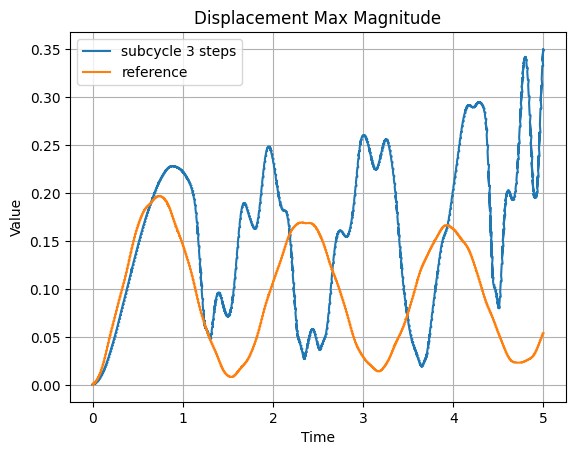

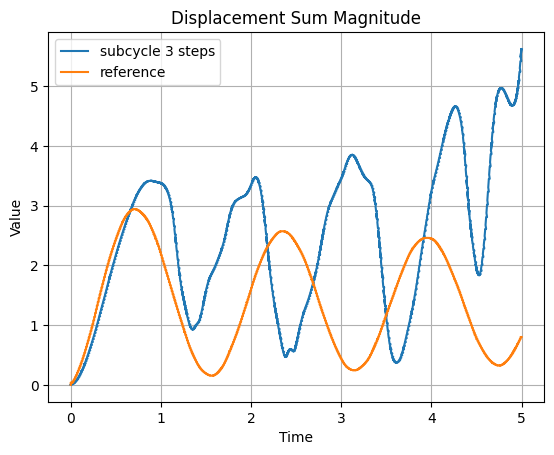

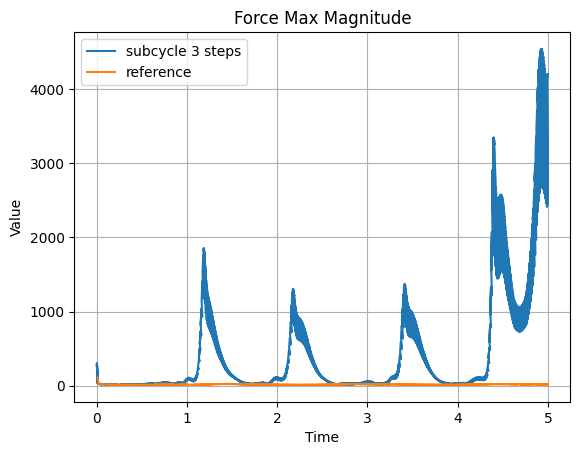

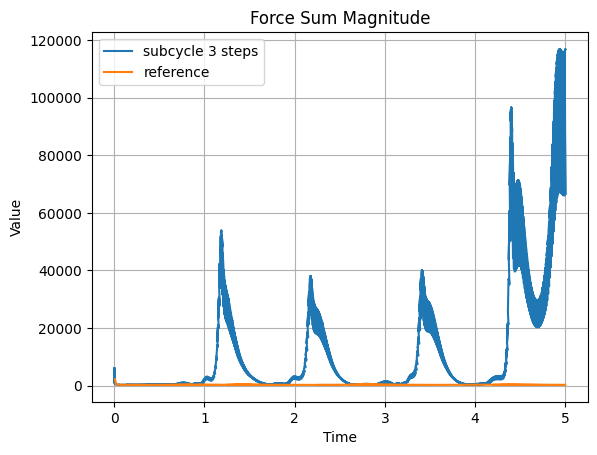

In [105]:
# Plot Displacement Max Magnitude
plt.figure()
plt.plot(subcycle3[0][0::4], subcycle3[1], label="subcycle 3 steps")
plt.plot(reference[0][0::4], reference[1], label="reference")
plt.title("Displacement Max Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

# Plot Displacement Sum Magnitude
plt.figure()
plt.plot(subcycle3[0][1::4], subcycle3[2], label="subcycle 3 steps")
plt.plot(reference[0][1::4], reference[2], label="reference")
plt.title("Displacement Sum Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

# Plot Force Max Magnitude
plt.figure()
plt.plot(subcycle3[0][2::4], subcycle3[3], label="subcycle 3 steps")
plt.plot(reference[0][2::4], reference[3], label="reference")
plt.title("Force Max Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

# Plot Force Sum Magnitude
plt.figure()
plt.plot(subcycle3[0][3::4], subcycle3[4], label="subcycle 3 steps")
plt.plot(reference[0][3::4], reference[4], label="reference")
plt.title("Force Sum Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

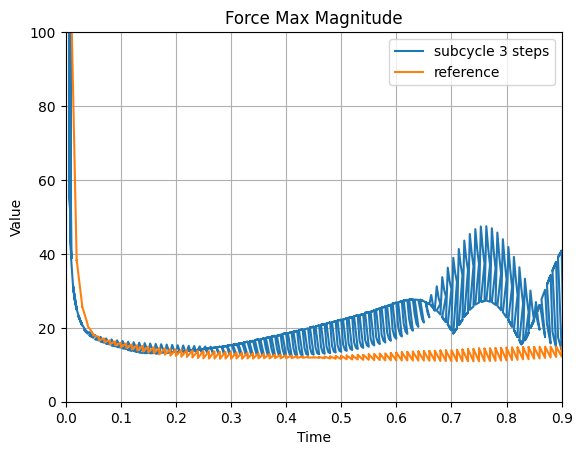

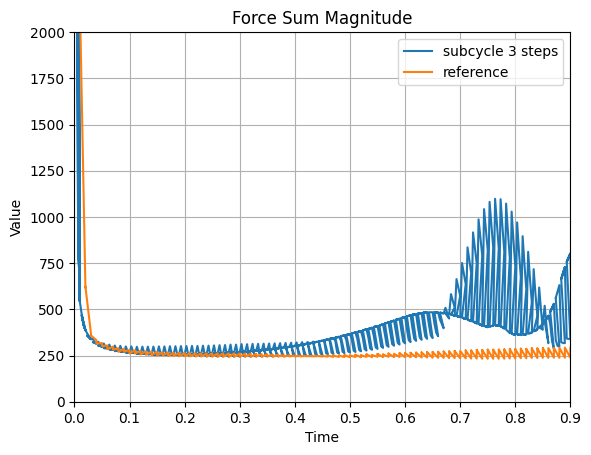

In [106]:
max_time = 0.9

# Plot Force Max Magnitude
plt.figure()
plt.plot(subcycle3[0][2::4], subcycle3[3], label="subcycle 3 steps")
plt.plot(reference[0][2::4], reference[3], label="reference")
plt.title("Force Max Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xlim(0, max_time)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

# Plot Force Sum Magnitude
plt.figure()
plt.plot(subcycle3[0][3::4], subcycle3[4], label="subcycle 3 steps")
plt.plot(reference[0][3::4], reference[4], label="reference")
plt.title("Force Sum Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xlim(0, max_time)
plt.ylim(0, 2000)
plt.legend()
plt.grid(True)

In [110]:
timesteps[::3]

array([0.  , 0.  , 0.  , ..., 4.99, 4.99, 5.  ])

In [119]:
timesteps = subcycle3[0][0::4]
timesteps3 = timesteps[::3]

def get_final_iteration_indices(timesteps):
    iteration_count = []
    final_iteration_indices = []

    iterations = 0
    time = timesteps[0]

    for i, t in enumerate(timesteps):
        if t == time:
            iterations += 1
        else:
            iteration_count.append(iterations)
            previous_index_in_original = (i - 1)
            final_iteration_indices.append(previous_index_in_original)
            
            iterations = 1
            time = t

    iteration_count = np.array(iteration_count)
    final_iteration_indices = np.array(final_iteration_indices)
    return final_iteration_indices, iteration_count

window_subcycle3, iterations_subcycle3 = get_final_iteration_indices(timesteps3)
window_subcycle3 = window_subcycle3 * 3 + 2
window_reference, iterations_reference = get_final_iteration_indices(reference[0][0::4])

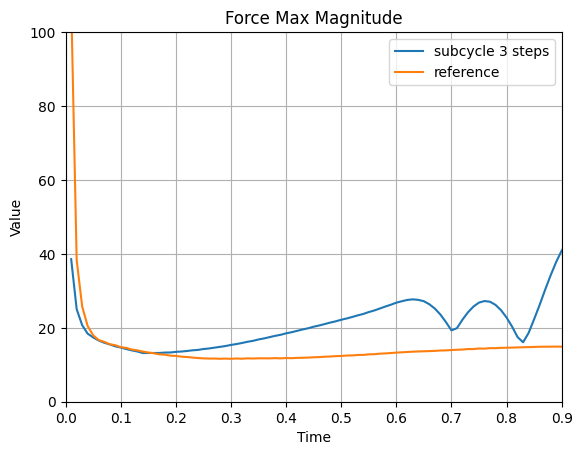

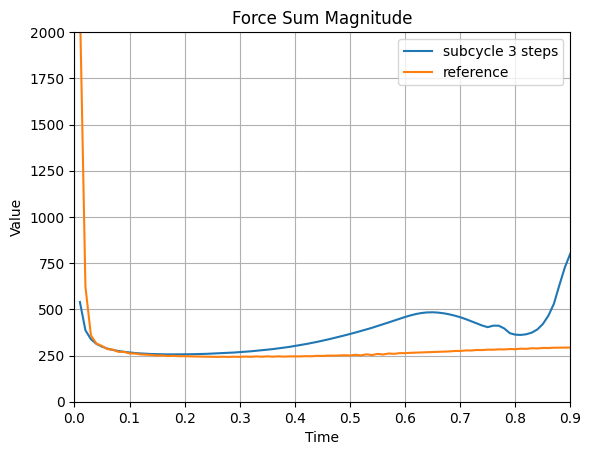

In [120]:
max_time = 0.9

# Plot Force Max Magnitude
plt.figure()
plt.plot(subcycle3[0][2::4][window_subcycle3], subcycle3[3][window_subcycle3], label="subcycle 3 steps")
plt.plot(reference[0][2::4][window_reference], reference[3][window_reference], label="reference")
plt.title("Force Max Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xlim(0, max_time)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

# Plot Force Sum Magnitude
plt.figure()
plt.plot(subcycle3[0][3::4][window_subcycle3], subcycle3[4][window_subcycle3], label="subcycle 3 steps")
plt.plot(reference[0][3::4][window_reference], reference[4][window_reference], label="reference")
plt.title("Force Sum Magnitude")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xlim(0, max_time)
plt.ylim(0, 2000)
plt.legend()
plt.grid(True)

In [132]:
# subcycle3[0][3::4][window_subcycle3]
# subcycle3[4][window_subcycle3]
for i in range(len(window_subcycle3)):
    print("Subcycling window ", i)
    print(f"{subcycle3[0][3::4][window_subcycle3[i]-2]:.3f}, {subcycle3[4][window_subcycle3[i]]-2:.2f}")
    print(f"{subcycle3[0][3::4][window_subcycle3[i]-1]:.3f}, {subcycle3[4][window_subcycle3[i]]-1:.2f}")
    print(f"{subcycle3[0][3::4][window_subcycle3[i]]:.3f}, {subcycle3[4][window_subcycle3[i]]:.2f}")

# reference[0][3::4][window_reference]
# reference[4][window_reference]

Subcycling window  0
0.003, 537.70
0.007, 538.70
0.010, 539.70
Subcycling window  1
0.013, 384.61
0.017, 385.61
0.020, 386.61
Subcycling window  2
0.023, 336.20
0.027, 337.20
0.030, 338.20
Subcycling window  3
0.033, 310.86
0.037, 311.86
0.040, 312.86
Subcycling window  4
0.043, 296.10
0.047, 297.10
0.050, 298.10
Subcycling window  5
0.053, 285.37
0.057, 286.37
0.060, 287.37
Subcycling window  6
0.063, 278.07
0.067, 279.07
0.070, 280.07
Subcycling window  7
0.073, 272.36
0.077, 273.36
0.080, 274.36
Subcycling window  8
0.083, 267.83
0.087, 268.83
0.090, 269.83
Subcycling window  9
0.093, 264.42
0.097, 265.42
0.100, 266.42
Subcycling window  10
0.103, 261.58
0.107, 262.58
0.110, 263.58
Subcycling window  11
0.113, 259.24
0.117, 260.24
0.120, 261.24
Subcycling window  12
0.123, 257.75
0.127, 258.75
0.130, 259.75
Subcycling window  13
0.133, 256.11
0.137, 257.11
0.140, 258.11
Subcycling window  14
0.143, 255.41
0.147, 256.41
0.150, 257.41
Subcycling window  15
0.153, 254.62
0.157, 255.62


In [133]:
for i in range(len(window_reference)):
    print("Reference window ", i)
    print(f"{reference[0][3::4][window_reference[i]]:.3f}, {reference[4][window_reference[i]]:.2f}")

Reference window  0
0.010, 2156.23
Reference window  1
0.020, 622.83
Reference window  2
0.030, 358.38
Reference window  3
0.040, 314.81
Reference window  4
0.050, 301.73
Reference window  5
0.060, 284.53
Reference window  6
0.070, 281.87
Reference window  7
0.080, 269.77
Reference window  8
0.090, 269.86
Reference window  9
0.100, 261.36
Reference window  10
0.110, 260.97
Reference window  11
0.120, 256.23
Reference window  12
0.130, 254.31
Reference window  13
0.140, 252.96
Reference window  14
0.150, 249.83
Reference window  15
0.160, 250.62
Reference window  16
0.170, 247.31
Reference window  17
0.180, 248.63
Reference window  18
0.190, 246.10
Reference window  19
0.200, 246.73
Reference window  20
0.210, 245.43
Reference window  21
0.220, 244.92
Reference window  22
0.230, 244.73
Reference window  23
0.240, 243.42
Reference window  24
0.250, 243.95
Reference window  25
0.260, 242.47
Reference window  26
0.270, 243.47
Reference window  27
0.280, 242.23
Reference window  28
0.290, 2